# US–Hong Kong Dual-Listing Arbitrage

**Question.** Six Chinese companies trade both as ADRs in New York and as ordinary shares in Hong Kong. After
adjusting for the ADR ratio and USD/HKD, the two prices should be equal. Does the gap mean-revert fast enough
for a market-neutral z-score strategy to profit **after realistic costs, out-of-sample**?

**How to read this notebook.** Each section states what it does and why in a few lines; all logic lives in
`src/` (unit-tested in `tests/` on synthetic data). Every number quoted at the end is printed from the computations above it.

**Discipline built in:** no look-ahead (signal at the US open uses only data known then); parameters frozen
on 2021-04-19 → 2023-12-31 before the out-of-sample period (2024-01-01 → 2026-09-30) was opened, and the OOS
period was run once; every parameter combination tried is logged (`results/grid_log.csv`); every dropped or
corrected data point is logged (`results/logs/`); a placebo test proves the engine cannot profit from pure
timing noise.

In [1]:
REFRESH_DATA = False   # True: re-download from Yahoo Finance (creates a new dated snapshot); default = offline snapshot
RERUN_GRID   = False   # True: re-run the 72-run in-sample grid (logged to results/grid_log_rerun.csv, not the main log)

import warnings; warnings.filterwarnings("ignore", category=DeprecationWarning)
import json
import numpy as np, pandas as pd
from IPython.display import Image, display
import config
from src import data, clean, spread, analysis, strategy, backtest, metrics, plots, holdout
from src.strategy import Params
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
pct = lambda x: f"{x * 100:+.2f}%"
FROZEN = Params(**config.FROZEN_PARAMS)
print("OOS unlocked:", config.ALLOW_OOS, "| frozen parameters:", FROZEN)

OOS unlocked: True | frozen parameters: Params(L=120, k=2.5, exit_z=0.5, H=10, stop_z=4.0)


## 1. Data Acquisition

Daily prices for the 6 ADRs, their 6 Hong Kong lines and HKD=X from Yahoo Finance (`yfinance`,
`auto_adjust=False`: split-adjusted but **not** dividend-adjusted, so the spread level is real). Downloaded once
into `data/raw/` (one dated CSV per ticker); everything below reads that snapshot offline.

In [2]:
if REFRESH_DATA:
    data.download_raw()
frames = data.load_raw()                       # offline; OOS dates allowed because config.ALLOW_OOS is True
manifest = json.load(open(config.RAW_DIR / "manifest.json"))
print(f"Snapshot downloaded {manifest['download_date']} with yfinance {manifest['yfinance_version']};",
      f"window {manifest['start_inclusive']} to {manifest['end_exclusive']} (exclusive)")
pd.DataFrame(config.PAIRS, index=["US ADR", "HK line", "HK shares per ADR"])

Snapshot downloaded 2026-10-07 with yfinance 1.7.0; window 2019-01-01 to 2026-10-08 (exclusive)


,Alibaba,JD,NetEase,YumChina,Baidu,TripCom
US ADR,BABA,JD,NTES,YUMC,BIDU,TCOM
HK line,9988.HK,9618.HK,9999.HK,9987.HK,9888.HK,9961.HK
HK shares per ADR,8,2,5,1,8,1


In [3]:
q_is, _ = data.quality_report({t: f.loc[config.START:config.IS_END] for t, f in frames.items()})
q_oos = pd.read_csv(config.LOG_DIR / "raw_quality_oos.csv")
cols = ["ticker", "first_date", "last_date", "n_rows", "missing_close", "zero_volume", "open_outside_range", "n_dividends", "n_splits"]
print("In-sample data quality (2021-04-19 .. 2023-12-31). Zero-volume rows are Yahoo's single-price bars on HK half-days; FX has no volume.")
q_is[cols]

In-sample data quality (2021-04-19 .. 2023-12-31). Zero-volume rows are Yahoo's single-price bars on HK half-days; FX has no volume.


,ticker,first_date,last_date,n_rows,missing_close,zero_volume,open_outside_range,n_dividends,n_splits
0,BABA,2021-04-19,2023-12-29,681,0,0,0,1,0
1,9988.HK,2021-04-19,2023-12-29,666,0,1,0,1,0
2,JD,2021-04-19,2023-12-29,681,0,0,0,2,0
3,9618.HK,2021-04-19,2023-12-29,666,0,1,0,2,0
4,NTES,2021-04-19,2023-12-29,681,0,0,0,11,0
5,9999.HK,2021-04-19,2023-12-29,666,0,1,0,11,0
6,YUMC,2021-04-19,2023-12-29,681,0,0,0,11,0
7,9987.HK,2021-04-19,2023-12-29,666,0,1,0,11,0
8,BIDU,2021-04-19,2023-12-29,681,0,0,0,0,0
9,9888.HK,2021-04-19,2023-12-29,666,0,4,0,0,0


## 2. Cleaning and the spread

- **Align** each pair on days both markets traded; every other day is logged with a reason (US/HK holiday from
  `exchange_calendars`, or unexplained missing data — e.g. HK typhoon closures).
- **Bad HK bars**: Yahoo's single-price, zero-volume bars are dropped on normal days (e.g. 2022-03-14) and kept on
  half-days with the open marked unreliable.
- **FX**: HKD=X close of the *previous* day — Yahoo stamps its FX close after the US open, so same-day FX would be look-ahead.
- **Dividends**: when the two legs go ex on different days, the dividend is added back to the leg that went first
  (signal only; P&L uses raw prices plus cash dividends).

**Spread (morning reading):** `ln(US open_t) − ln(N × HK close_t / FX)`. HK has closed before New York opens, so
both prices are known at the US open. Positive = ADR rich.

Dropped pair-dates, 2021-04-19 .. 2026-09-30, by reason:


pair,Alibaba,Baidu,JD,NetEase,TripCom,YumChina
reason,,,,,,
"FX missing (t-1, beyond 1-day fill)",1,1,1,1,1,1
HK holiday (XHKG closed),64,64,64,64,64,64
HK missing data (XHKG open),2,2,2,2,2,2
US holiday (XNYS closed),38,37,37,38,37,37
unreliable HK bar,0,2,1,0,2,1


Dividend events by action: {'add back HK dividend (HK ex first)': 18, 'add back US dividend (US ex first)': 2, 'none (same ex-date)': 38, 'none (unmatched; check manually)': 2}
Spreads with |s| > 10% (kept, reviewed): 6


,date,pair,spread,spread_eve
0,2023-03-28,Alibaba,0.105,-0.007
1,2025-02-20,Alibaba,0.102,-0.001
2,2022-03-10,JD,-0.136,-0.004
3,2022-04-11,NetEase,0.108,-0.005
4,2021-03-26,Baidu,-0.144,-0.036
5,2026-01-14,TripCom,-0.147,-0.001


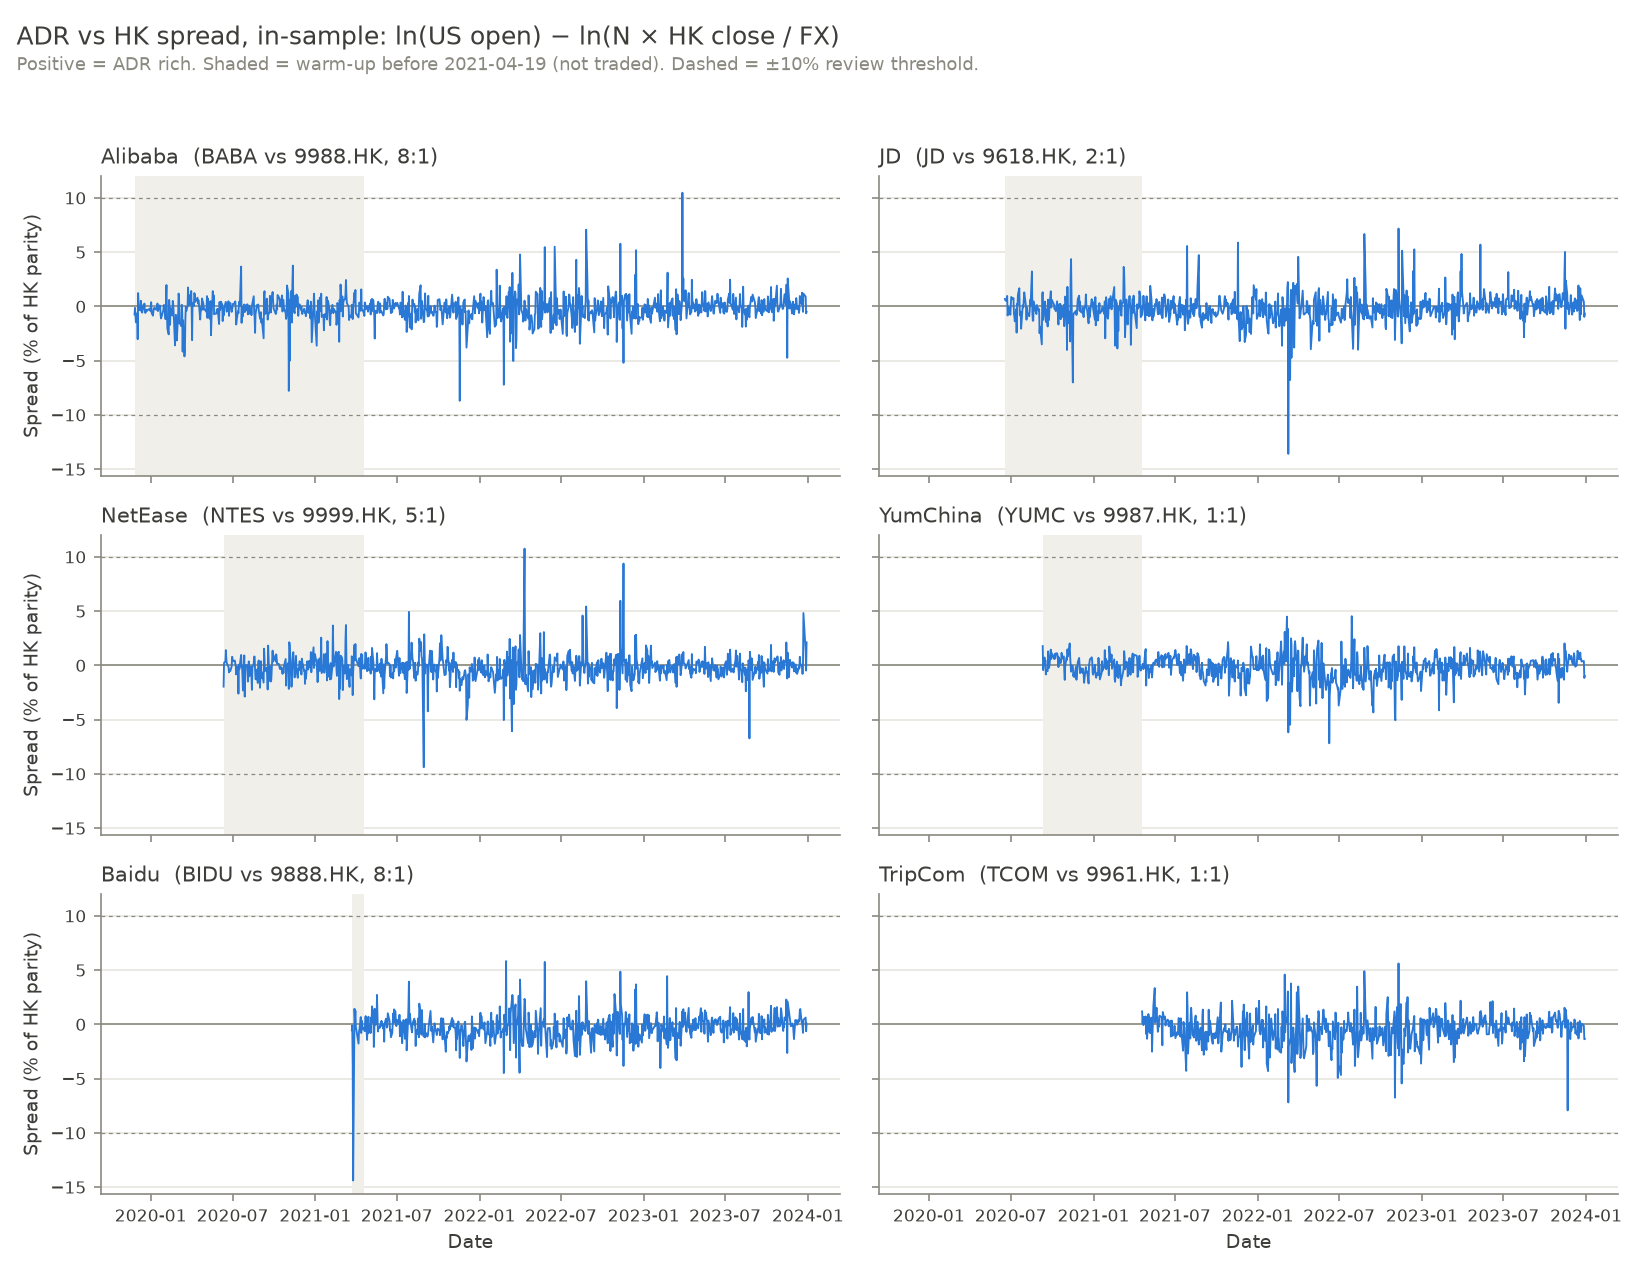

In [4]:
spreads = spread.build_spreads(clean.clean_all(frames))      # writes results/logs/*.csv
flags = spread.save_spreads(spreads)
is_spreads = analysis.in_sample(spreads)
dropped = pd.read_csv(config.LOG_DIR / "dropped_dates.csv", parse_dates=["date"])
dropped = dropped[dropped["date"].between(config.START, config.END)]
print("Dropped pair-dates, 2021-04-19 .. 2026-09-30, by reason:")
display(dropped.groupby(["reason", "pair"]).size().unstack(fill_value=0))
div = pd.read_csv(config.LOG_DIR / "dividend_corrections.csv")
print("Dividend events by action:", div.groupby("action").size().to_dict())
print(f"Spreads with |s| > 10% (kept, reviewed): {len(flags)}")
display(flags[["date", "pair", "spread", "spread_eve"]].round({"spread": 3, "spread_eve": 3}))
plots.plot_spreads(spreads[spreads["date"] <= config.IS_END])
display(Image(str(config.FIGURES_DIR / "spreads_in_sample.png")))

Every flagged spike is a one-day jump that disappears the next day — news arriving after Hong Kong closed and
before New York opened. That observation drives the next section.

## 3. Does the gap mean-revert? (in-sample only)

The two markets never trade at the same time. The morning spread compares an HK price that is 5½–6½ hours old
with a fresh US price, so it mixes **a real mispricing** with **timing noise** that HK absorbs at its next open
(and that nobody can trade). Diagnostics:

- AR(1) on the spread → half-life; ADF test.
- A persistence split (ARMA(1,1) = persistent AR(1) + noise) → how much of the variance actually persists.
- The **two-reading spread**: average the morning reading with an evening reading (US close of the previous
  session vs HK open today, where the *US* side is stale). Timing noise comes from different news windows and
  partly cancels; a real mispricing appears in both. This was **pre-registered** as a secondary signal before any backtest.

ar1_beta  ar1_half_life_days  adf_p  acf_lag1  persistent_share  persistent_half_life_days
measure   pair                                                                                                
spread    Alibaba     -0.977               0.183    0.0     0.023               NaN                      0.160
          JD          -0.946               0.238    0.0     0.054             0.067                      3.402
          NetEase     -0.926               0.266    0.0     0.074               NaN                        NaN
          YumChina    -0.750               0.500    0.0     0.250             0.477                      1.073
          Baidu       -0.949               0.233    0.0     0.051               NaN                        NaN
          TripCom     -0.906               0.293    0.0     0.094               NaN                        NaN
spread_2r Alibaba     -0.926               0.266    0.0     0.074             0.279                      0.520
          JD          -0.849               0.366    0.0     0.151             0.226                      1.711
          NetEase     -0.867               0.344    0.0     0.133             0.331                      0.762
          YumChina    -0.662               0.640    0.0     0.338             0.612                      1.169
          Baidu       -0.889               0.315    0.0     0.111             0.180                      1.430
          TripCom     -0.843               0.374    0.0     0.157               NaN                      0.166

,corr_morning_vs_next_evening,std_spread,std_spread_2r,common_r2_spread
pair,,,,
Alibaba,-0.014,0.013,0.009,0.610
JD,0.040,0.014,0.010,0.658
NetEase,0.078,0.014,0.010,0.476
YumChina,0.275,0.012,0.011,0.376
Baidu,0.062,0.012,0.009,0.638
TripCom,0.166,0.014,0.011,0.532


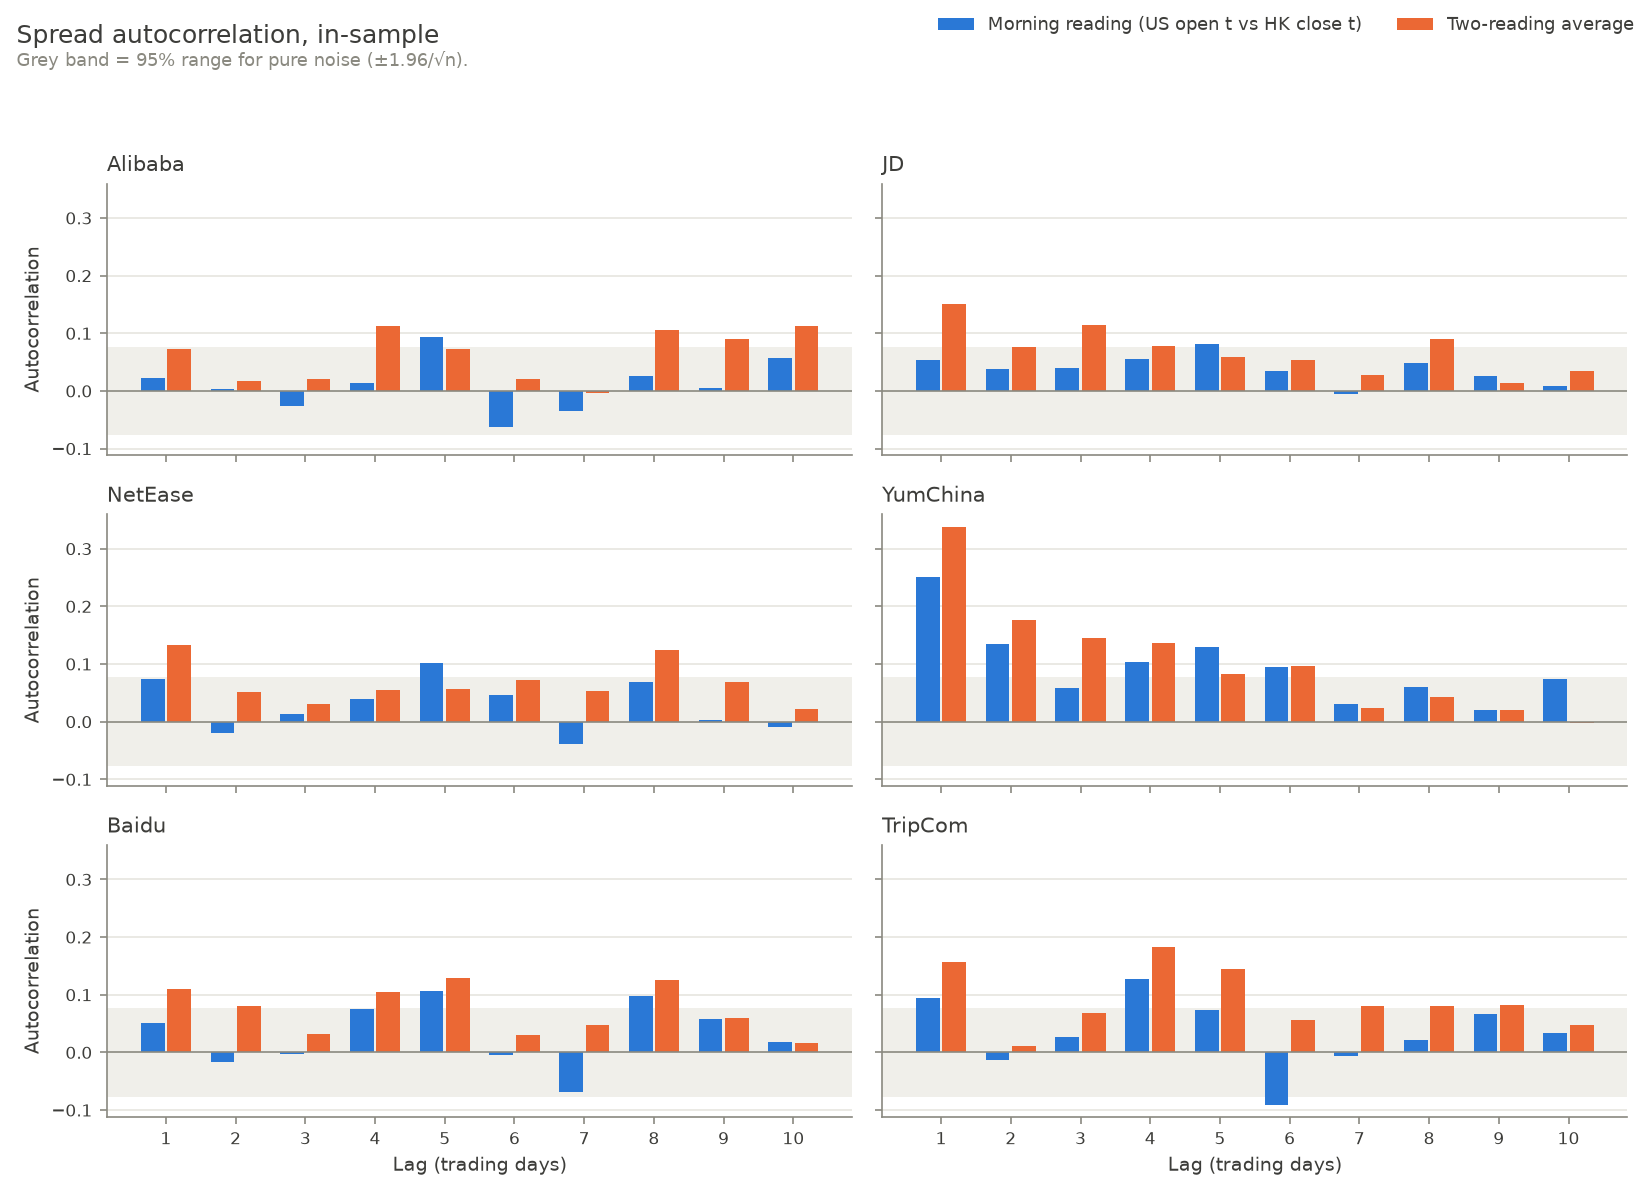

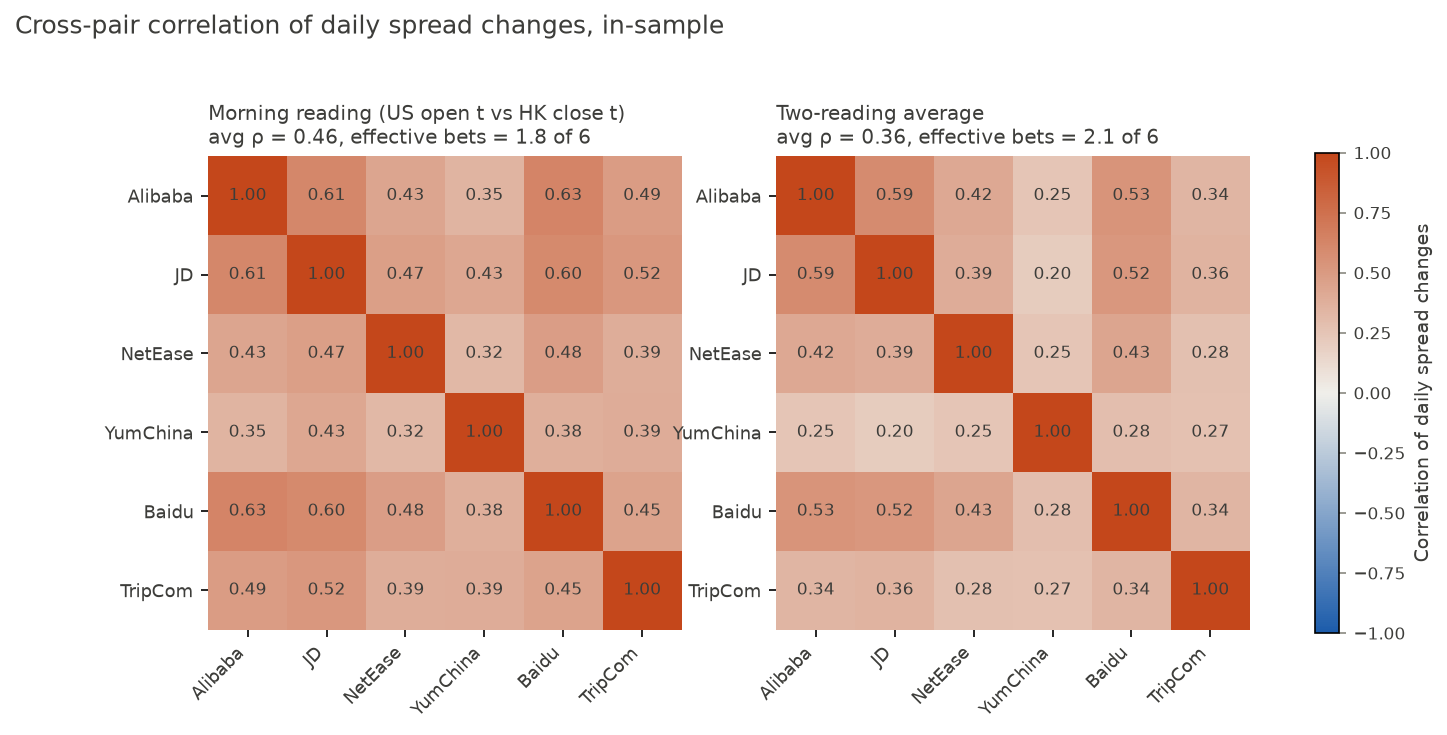

In [5]:
tables = analysis.run_analysis(spreads)
mr = tables["mean_reversion"].set_index(["measure", "pair"])
display(mr[["ar1_beta", "ar1_half_life_days", "adf_p", "acf_lag1", "persistent_share", "persistent_half_life_days"]].round(3))
td = tables["timing_diagnostics"].set_index("pair")
display(td[["corr_morning_vs_next_evening", "std_spread", "std_spread_2r", "common_r2_spread"]].round(3))
plots.plot_acf(is_spreads, config.FIGURES_DIR / "spread_acf.png")
display(Image(str(config.FIGURES_DIR / "spread_acf.png")))
corrs = {m: analysis.change_correlations(is_spreads, m) for m in ("spread", "spread_2r")}
plots.plot_corr_heatmaps(corrs, config.FIGURES_DIR / "spread_change_corr.png")
display(Image(str(config.FIGURES_DIR / "spread_change_corr.png")))

**Reading.** β ≈ −1 (half-life well under a day) looks like fast arbitrage but is mostly timing noise: two
readings of the same pair 12 hours apart barely correlate, and ~half of each pair's variance is shared
China-wide news. ADF rejects a unit root everywhere, which is uninformative for near-white noise. A small
persistent component exists (clearest for Yum China), and the six pairs behave like only ~2 independent bets.
The capture-vs-cost estimate below predicted, *before any backtest*, that costs would roughly match the edge.

In [6]:
tables["capture_vs_cost"].assign(**{c: lambda d, c=c: d[c] * 100 for c in ["entry_deviation", "expected_capture", "round_trip_cost", "capture_minus_cost"]}).round(2)

,pair,measure,acf_lag1,entry_deviation,expected_capture,round_trip_cost,capture_minus_cost
0,Alibaba,spread,0.02,2.69,0.06,0.54,-0.48
1,JD,spread,0.05,2.84,0.15,0.54,-0.39
2,NetEase,spread,0.07,2.74,0.20,0.74,-0.54
3,YumChina,spread,0.25,2.47,0.62,0.74,-0.12
4,Baidu,spread,0.05,2.42,0.12,0.74,-0.62
5,TripCom,spread,0.09,2.83,0.27,0.74,-0.47
6,Alibaba,spread_2r,0.07,1.82,0.13,0.54,-0.41
7,JD,spread_2r,0.15,2.01,0.30,0.54,-0.24
8,NetEase,spread_2r,0.13,1.94,0.26,0.74,-0.48
9,YumChina,spread_2r,0.34,2.12,0.72,0.74,-0.02


## 4. Strategy

**Signal:** `z_t = (s_t − mean_L) / std_L`, rolling mean and std over the previous L days **up to t−1**.

**Positions are held in the spread** (+1 = long US / short HK, −1 = short US / long HK):

| Situation | Action |
|---|---|
| flat, k < z ≤ 4 (ADR rich) | enter −1 |
| flat, −4 ≤ z < −k (ADR cheap) | enter +1 |
| −1 and z < exit_z, or +1 and z > −exit_z | exit (reverted) |
| \|z\| > 4 | exit, and never enter (news, not mispricing) |
| held H decision days | exit |
| exit day | no re-entry the same day |

**Execution:** signal at the US open on day t → US leg trades at the **US close on t**, HK leg at the **next HK
open**. Each leg buys 50% of pair equity worth of shares and **holds the share count** until exit; each leg is
marked on its own exchange calendar in USD, with dividends. Costs are deducted as they occur (HK stamp duty
0.10%, levies 0.01%, commission 0.03%, half-spread 0.05–0.10% per side; borrow 1% p.a. on the short leg).
The position state machine is one loop over T days with O(1) work per day: **O(T)**.

**Timing, checked by hand.** A 5-day example (enter on day 2, exit on day 4) computed by the engine and by an
independent shares-and-dollars ledger:

In [7]:
from tests.timing_example import walkthrough, engine_result, dollar_ledger
display(walkthrough().round(4))
eq = engine_result()["equity"]
print(f"Trade P&L: engine {pct(eq.iloc[-1] - 1)}  |  independent ledger {pct(dollar_ledger()['equity'].iloc[-1] / 1e6 - 1)}")

,decision,US P&L %,HK P&L %,pair (engine) %,"pair (ledger, hold) %",pair (old rebalanced) %,equity (engine)
date,,,,,,,
2022-04-25,0,0.000,0.0000,0.0000,0.0000,0.0000,1.0000
2022-04-26,1,0.000,0.0000,0.0000,0.0000,0.0000,1.0000
2022-04-27,1,5.000,-2.9412,2.0588,2.0588,2.0588,1.0206
2022-04-28,0,-5.389,4.3228,-1.0663,-1.0663,-0.8333,1.0097
2022-04-29,0,0.000,0.4855,0.4855,0.4855,0.5051,1.0146


Trade P&L: engine +1.46%  |  independent ledger +1.46%


**Placebo.** Two listings of one perfectly priced stock, observed at the real session times (HK before US), with
**zero** mispricing. The spread *looks* mean-reverting and the strategy trades — but an honest engine must earn
nothing. Computing P&L from spread changes (the common mistake) shows a large fake profit on the same trades.

In [8]:
from tests.synthetic import simulate_pair
sim = simulate_pair(10_000, sigma=0.01, seed=4)            # ~40 simulated years, no mispricing
pl = backtest.run_pair(sim["spreads"], sim["us"], sim["hk"], sim["fx"], Params(L=40, k=1.5, exit_z=0.0, H=10),
                       start=str(sim["spreads"]["date"].iloc[0].date()), hk_drop=pd.DatetimeIndex([]))
s = sim["spreads"].set_index("date")["spread"]; pos = pl["decisions"]["position"]
naive = (pos.shift(1) * s.diff()).loc[pos.index].fillna(0.0)
print(f"Trades: {len(pl['trades'])} | engine gross Sharpe: {metrics.sharpe(pl['daily']['pair_ret']):+.2f} "
      f"| wrong spread-change P&L Sharpe: {metrics.sharpe(naive):+.2f}")

Trades: 1119 | engine gross Sharpe: +0.05 | wrong spread-change P&L Sharpe: +5.76


## 5. Backtest: in-sample grid and frozen parameters

36 settings (L ∈ {20, 60, 120}, k ∈ {1.5, 2.0, 2.5}, exit_z ∈ {0, 0.5}, H ∈ {5, 10}) × 2 signals = 72 runs on
in-sample data at 1× costs, every run logged. The setting is chosen on a **plateau** (good neighbourhood), not the
single best cell, then frozen in `config.FROZEN_PARAMS` and committed before the OOS data were opened.

72 runs, 21.2 s in total (0.29 s per run)
spread   : gross Sharpe +0.33..+0.57, net Sharpe -0.66..+0.06, net > 0 in 5/36 cells
spread_2r: gross Sharpe +0.42..+0.78, net Sharpe -0.90..+0.15, net > 0 in 11/36 cells


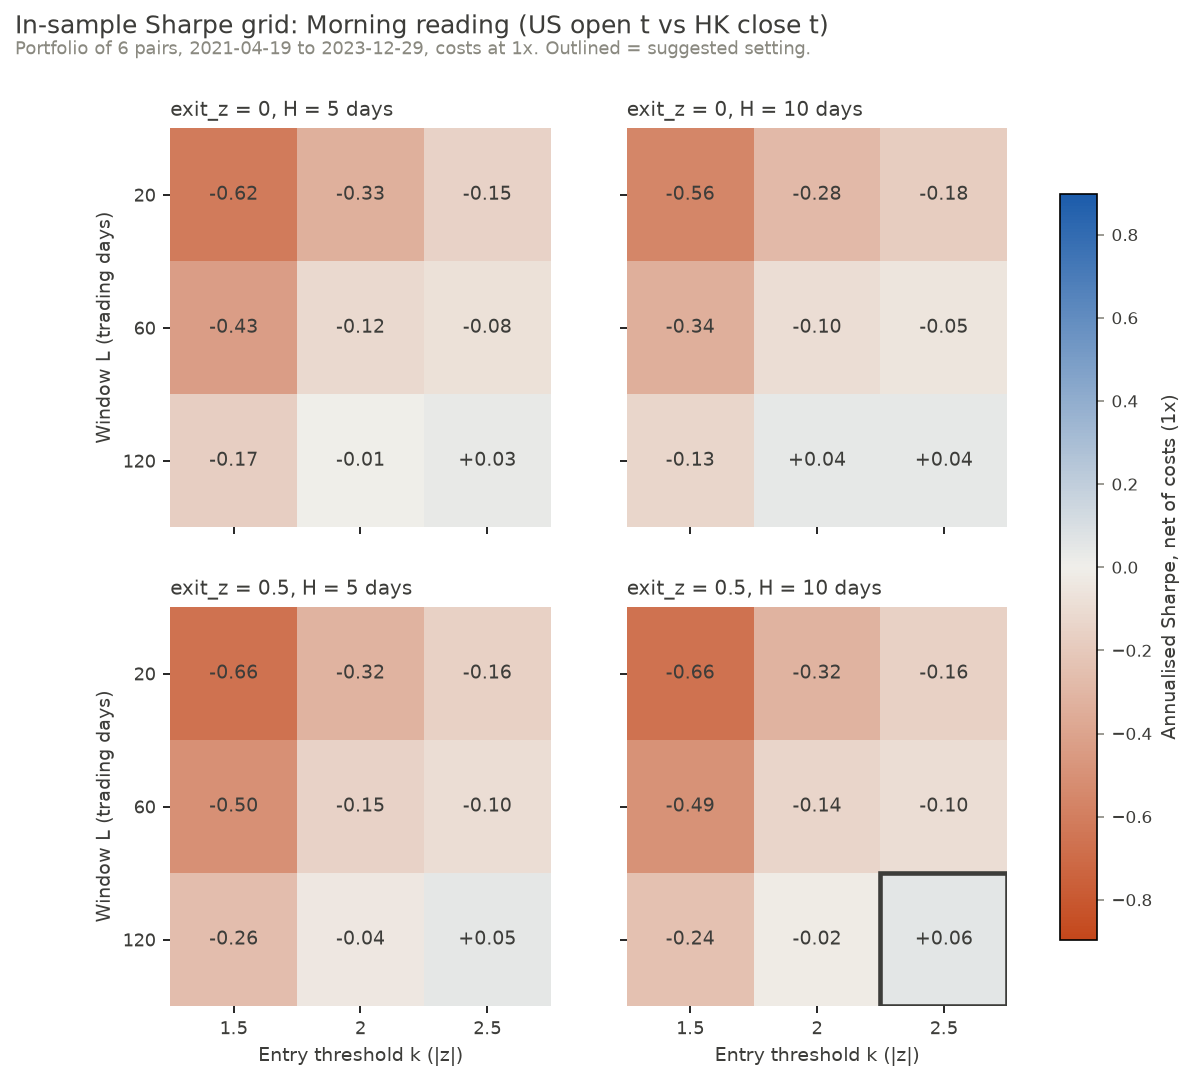

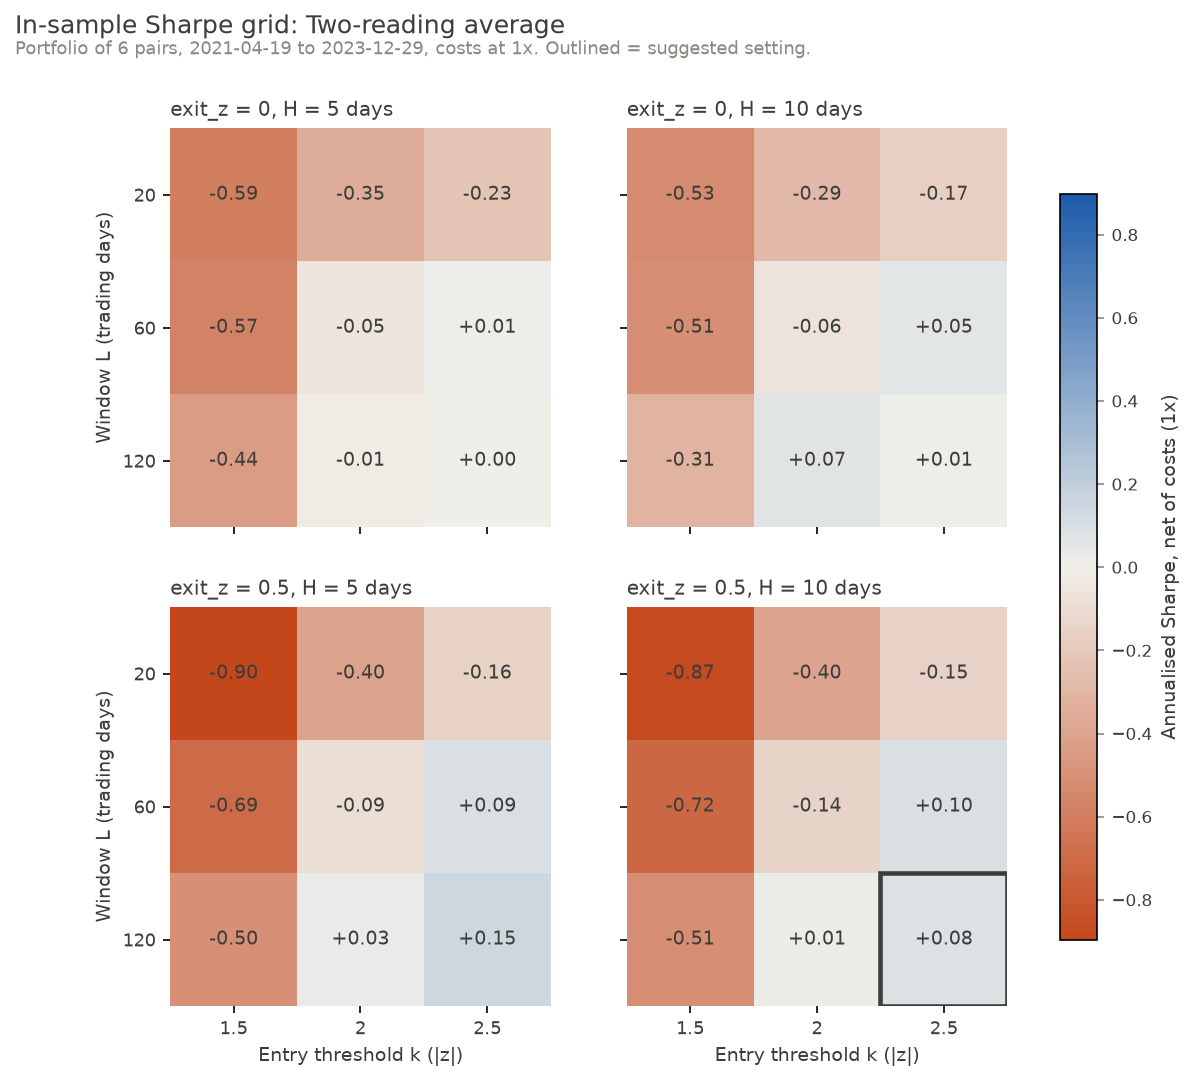

,signal,sharpe,sharpe_gross,nbhd_mean,nbhd_min,n_trades
35,spread,0.056,0.357,0.006,-0.097,75
35,spread_2r,0.081,0.514,0.070,0.012,72


In [9]:
if RERUN_GRID:
    grid, grid_pairs, secs = backtest.run_grid(spreads, frames, log_path=config.RESULTS_DIR / "grid_log_rerun.csv")
else:
    grid = pd.read_csv(config.RESULTS_DIR / "grid_results.csv"); secs = grid["elapsed_sec"].sum()
print(f"72 runs, {secs:.1f} s in total ({grid['elapsed_sec'].mean():.2f} s per run)")
for sig in ("spread", "spread_2r"):
    g = grid[grid["signal"] == sig]
    print(f"{sig:9s}: gross Sharpe {g['sharpe_gross'].min():+.2f}..{g['sharpe_gross'].max():+.2f}, "
          f"net Sharpe {g['sharpe'].min():+.2f}..{g['sharpe'].max():+.2f}, net > 0 in {(g['sharpe'] > 0).sum()}/36 cells")
vlim = float(np.nanmax(np.abs(grid["sharpe"])))
for sig in ("spread", "spread_2r"):
    plots.plot_sharpe_heatmaps(grid, sig, config.FIGURES_DIR / f"sharpe_grid_{sig}.png", vlim=vlim, mark=config.FROZEN_PARAMS)
    display(Image(str(config.FIGURES_DIR / f"sharpe_grid_{sig}.png")))
scored = pd.concat([metrics.plateau_scores(grid[grid["signal"] == s].reset_index(drop=True)) for s in ("spread", "spread_2r")])
f = config.FROZEN_PARAMS
scored[(scored.L == f["L"]) & (scored.k == f["k"]) & (scored.exit_z == f["exit_z"]) & (scored.H == f["H"])][
    ["signal", "sharpe", "sharpe_gross", "nbhd_mean", "nbhd_min", "n_trades"]].round(3)

Gross Sharpe is positive in every cell; after costs almost everything is ≈ 0. Net Sharpe improves steadily toward
long windows and high thresholds (fewer, larger-gap trades against a fixed cost per trade). Frozen choice:
**L = 120, k = 2.5, exit_z = 0.5, H = 10** for both signals (outlined), on the plateau — not the H = 5 spike.

## 6. Results: in-sample vs out-of-sample (OOS run once, frozen parameters, costs 1×)

,,sharpe,sharpe_gross,ann_return,ann_vol,max_drawdown,n_trades,hit_rate,avg_days_held,cost_drag
signal,period,,,,,,,,,
spread,IS,0.056,0.357,0.002,0.050,-0.055,75,0.467,1.640,0.015
spread_2r,IS,0.081,0.514,0.002,0.034,-0.024,72,0.431,1.542,0.015
spread,OOS,0.221,0.875,0.004,0.018,-0.015,60,0.500,1.617,0.012
spread_2r,OOS,0.503,1.157,0.013,0.025,-0.019,80,0.525,2.075,0.017


Net Sharpe by pair:


IS              OOS          
         spread spread_2r spread spread_2r
Alibaba    0.01      0.17   0.11      0.13
JD        -0.17      0.07   0.37      0.67
NetEase    0.39     -0.11  -0.31     -0.17
YumChina   0.17      0.03   0.07     -0.02
Baidu      0.06      0.14   0.34      0.38
TripCom   -0.16     -0.14  -0.27      0.34

OOS t-statistic (Sharpe x sqrt(years)): spread 0.37, spread_2r 0.83


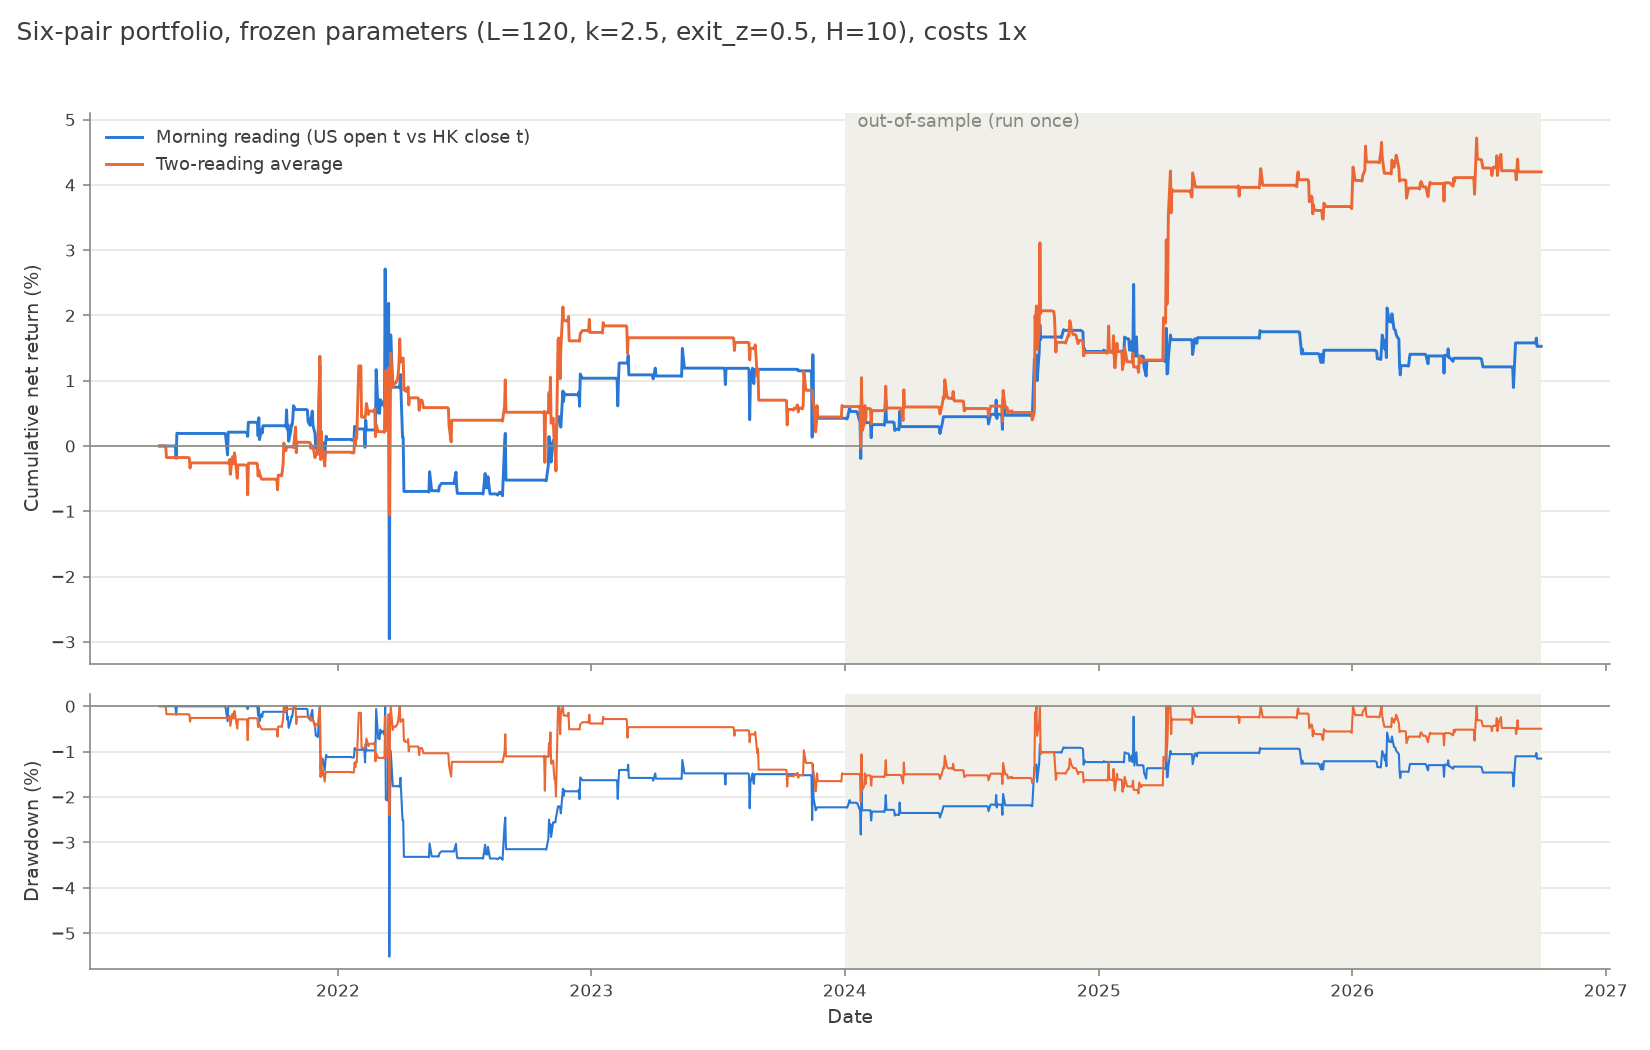

In [10]:
PERIODS = {"IS": (config.START, config.IS_END), "OOS": (config.OOS_START, config.END)}
runs, rows = {}, []
for per, (a, b) in PERIODS.items():
    for sig in ("spread", "spread_2r"):
        runs[per, sig] = backtest.run_backtest(spreads, frames, FROZEN, signal=sig, start=a, end=b)
        summ, by_pair = metrics.summarize_backtest(runs[per, sig])
        rows.append({"period": per, "signal": sig, **summ})
res = pd.DataFrame(rows).set_index(["signal", "period"])
display(res[["sharpe", "sharpe_gross", "ann_return", "ann_vol", "max_drawdown", "n_trades", "hit_rate", "avg_days_held", "cost_drag"]].round(3))
per_pair = pd.concat({(p, s): metrics.summarize_backtest(runs[p, s])[1]["sharpe"] for p, s in runs}, axis=1).astype(float)
print("Net Sharpe by pair:"); display(per_pair.round(2))
oos_t = {s: res.loc[(s, "OOS"), "sharpe"] * np.sqrt(metrics.years(runs["OOS", s]["portfolio"]["portfolio_ret"])) for s in ("spread", "spread_2r")}
print("OOS t-statistic (Sharpe x sqrt(years)):", ", ".join(f"{k} {v:.2f}" for k, v in oos_t.items()))
plots.plot_equity_is_oos({plots.MEASURE_LABELS[s]: (runs["IS", s]["portfolio"]["portfolio_ret"], runs["OOS", s]["portfolio"]["portfolio_ret"])
                          for s in ("spread", "spread_2r")}, config.FIGURES_DIR / "equity_is_oos.png")
display(Image(str(config.FIGURES_DIR / "equity_is_oos.png")))

**Is the OOS profit real?** Look at where it comes from: how much the best three trades contribute, and what is
left without them.

In [11]:
conc = {s: metrics.concentration(metrics.trade_table(runs["OOS", s])) for s in ("spread", "spread_2r")}
display(pd.DataFrame(conc).T.round(4))
print("Largest OOS trades (two-reading):")
metrics.trade_table(runs["OOS", "spread_2r"]).head(5).round(4)

,n_trades,total_contribution,top3_share,total_without_top3,median_trade_return
spread,60.0,0.0097,1.3052,-0.0029,-0.0000
spread_2r,80.0,0.0266,0.8152,0.0049,0.0002


Largest OOS trades (two-reading):


,pair,entry,direction,days_held,exit_reason,trade_return,contribution
0,JD,2025-04-03,-1,2,revert,0.0576,0.0096
1,Alibaba,2025-04-09,1,4,revert,0.0374,0.0062
2,JD,2024-09-30,1,5,stop,0.0351,0.0058
3,Baidu,2025-12-31,1,1,stop,0.0227,0.0038
4,Baidu,2024-09-26,-1,2,revert,0.0196,0.0033


**Known data gaps.** Yahoo has no US dividend matching some HK ex-dates (logged as "unmatched" in the dividend
logs). The prices are real, so the signal is unaffected; the P&L would only miss the cash dividend if a position
was open across the ex-date. Check:

In [12]:
def open_over(run, pair, ex):
    d = run["pairs"][pair]["daily"]
    held = d.loc[:pd.Timestamp(ex) - pd.Timedelta(days=1)].iloc[-1]
    return bool(held["us_pos"] != 0 or held["hk_pos"] != 0)
gaps = pd.read_csv(config.LOG_DIR / "dividend_corrections.csv").query("status != 'matched'")
gaps = gaps[gaps["hk_ex"].fillna(gaps["us_ex"]) >= config.START]
pd.DataFrame([{"pair": g.pair, "ex_date": g.hk_ex if isinstance(g.hk_ex, str) else g.us_ex, "status": g.status,
               **{f"position open ({s})": open_over(runs["OOS" if (g.hk_ex or "") >= config.OOS_START else "IS", s], g.pair,
                                                     g.hk_ex if isinstance(g.hk_ex, str) else g.us_ex) for s in ("spread", "spread_2r")}}
              for g in gaps.itertuples()])

,pair,ex_date,status,position open (spread),position open (spread_2r)
0,YumChina,2025-09-02,unmatched HK,False,False
1,YumChina,2025-12-02,unmatched HK,False,False


The OOS gains arrive in jumps on market shocks (Sep–Oct 2024 China stimulus rally, Apr 2025 tariff shock), are
concentrated in a handful of trades, have t-statistics below 1, and pair-level results flip sign between periods.

## 7. Sensitivity: costs, break-even and an execution upper bound

Cost multipliers 0 / 0.5 / 1 / 2; the multiplier at which net Sharpe hits zero; and an **upper bound that is not
tradable** — the US leg filled at the US open (the same moment the signal is computed).

In [13]:
sens = []
for per, (a, b) in PERIODS.items():
    for sig in ("spread", "spread_2r"):
        row = {"period": per, "signal": sig}
        for m in config.COST_MULTIPLIERS:
            row[f"Sharpe @{m:g}x"] = metrics.sharpe(backtest.run_backtest(spreads, frames, FROZEN, signal=sig, start=a, end=b,
                                                                           cost_multiplier=m)["portfolio"]["portfolio_ret"])
        row["break-even x"] = backtest.break_even_multiplier(spreads, frames, FROZEN, signal=sig, start=a, end=b)
        row["upper bound @1x (US at open)"] = metrics.sharpe(backtest.run_backtest(spreads, frames, FROZEN, signal=sig, start=a, end=b,
                                                                                    us_exec="open")["portfolio"]["portfolio_ret"])
        sens.append(row)
sens = pd.DataFrame(sens).set_index(["signal", "period"]); sens.round(2)

,,Sharpe @0x,Sharpe @0.5x,Sharpe @1x,Sharpe @2x,break-even x,upper bound @1x (US at open)
signal,period,,,,,,
spread,IS,0.36,0.21,0.06,-0.25,1.18,0.31
spread_2r,IS,0.51,0.30,0.08,-0.36,1.19,0.55
spread,OOS,0.87,0.55,0.22,-0.43,1.34,0.78
spread_2r,OOS,1.16,0.83,0.50,-0.14,1.78,0.53


Costs only modestly above the modelled level erase the edge (see the break-even column), and the modelled costs are optimistic (no market
impact, perfect auction fills, constant spreads; HK stamp duty was actually 0.13% from Aug 2021 to Nov 2023).
Filling the US leg at the open would help the morning signal a lot — most of its edge is gone by the US close.

## 8. Stock Connect

Southbound Stock Connect lets mainland investors buy only the HK leg. If segmentation matters, Alibaba's inclusion
(2024-09-10) should make HK relatively expensive (spread falls) or change how the gap behaves. Pre-registered
design: ±120 trading days before/after, compared with pairs whose Connect status did **not** change in that
window (Baidu, JD, Trip.com, NetEase out throughout; Yum China in throughout). NetEase (2026-06-30) and Baidu
(2026-09-07) are too recent: plots only.

,measure,stat,treated_change,controls_mean_change,diff_vs_controls,controls_min,controls_max,treated_rank_of_n,diff_vs_out_controls
0,spread,mean,0.0003,-0.0001,0.0004,-0.0016,0.0014,3 of 6,0.0005
1,spread_2r,mean,-0.0017,-0.0004,-0.0014,-0.0029,0.0020,5 of 6,-0.0008
0,spread,std,0.0056,0.0010,0.0046,-0.0003,0.0050,1 of 6,0.0056
1,spread_2r,std,0.0042,0.0015,0.0027,0.0005,0.0037,1 of 6,0.0033
0,spread,acf_lag1,-0.0786,-0.0488,-0.0299,-0.2778,0.1292,5 of 6,-0.0871
1,spread_2r,acf_lag1,-0.2039,-0.0708,-0.1331,-0.2753,0.1064,5 of 6,-0.1842


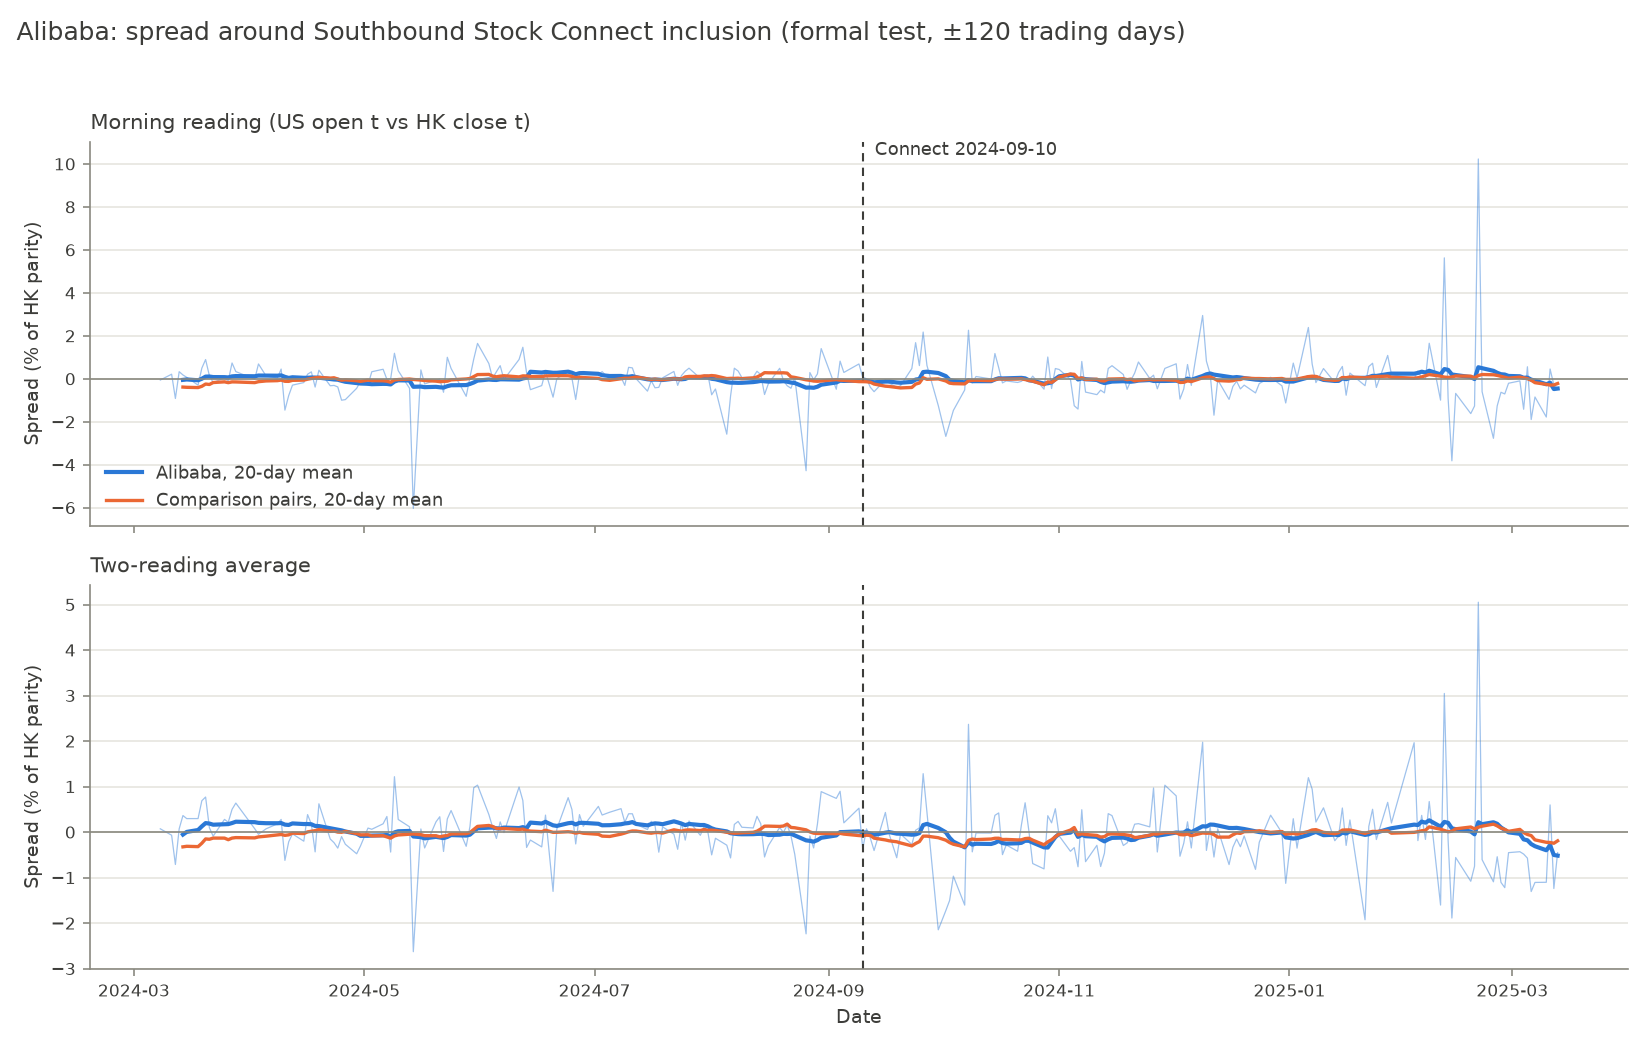

In [14]:
sp_end = spreads[spreads["date"] <= config.END]
study = analysis.connect_event_study(sp_end, config.CONNECT_FORMAL, config.CONNECT_EVENTS[config.CONNECT_FORMAL], config.CONNECT_CONTROLS)
vs = pd.concat([analysis.difference_vs_controls(study, st, config.CONNECT_STATUS_IN_WINDOW) for st in ("mean", "std", "acf_lag1")])
display(vs.round(4))
plots.plot_connect_event(sp_end, "Alibaba", config.CONNECT_EVENTS["Alibaba"], config.FIGURES_DIR / "connect_alibaba.png",
                         config.CONNECT_CONTROLS, config.CONNECT_WINDOW, config.END, " (formal test, ±120 trading days)")
display(Image(str(config.FIGURES_DIR / "connect_alibaba.png")))

Alibaba's change in spread level sits inside the control pairs' range: no HK premium appeared. Its volatility
rose most, but so did Yum China's (already in Connect), and the window contains the stimulus rally two weeks after
inclusion — confounded, not attributable to Connect.

## 9. Robustness: seven dual listings never used before

Pre-registered before any OOS result: same frozen parameters, code and costs, applied to other HK–US dual
listings chosen by rule — exclude ratio/ticker/domicile changes in the sample (Citi programme milestones, Yahoo
split records, company sources) and HK lines trading < HKD 20m/day; half-spread by HK liquidity tier.

,name,us,hk,ratio,median_hk_value_hkd_m,half_spread_pct,implied_ratio_median,decision,reasons
0,Bilibili,BILI,9626.HK,1,398.25,0.1,1.00,include,
1,Autohome,ATHM,2518.HK,4,1.38,,4.00,exclude,too thin: median HK value HKD 1.4m < 20m
2,XPeng,XPEV,9868.HK,2,500.21,0.1,1.99,include,
3,LiAuto,LI,2015.HK,2,586.99,0.1,1.99,include,
4,Hutchmed,HCM,0013.HK,5,44.99,0.2,4.92,include,
5,Weibo,WB,9898.HK,1,3.29,,1.00,exclude,too thin: median HK value HKD 3.3m < 20m
6,NIO,NIO,9866.HK,1,85.23,0.1,1.00,include,
7,KEHoldings,BEKE,2423.HK,3,18.41,,2.99,exclude,too thin: median HK value HKD 18.4m < 20m
8,TencentMusic,TME,1698.HK,2,1.19,,2.01,exclude,too thin: median HK value HKD 1.2m < 20m
9,ZTO,ZTO,2057.HK,1,22.93,0.2,1.00,include,


case              gross  net, borrow 1%  net, borrow 5%
signal    period                                       
spread    IS       0.36            0.03            0.02
          OOS      0.75           -0.04           -0.07
spread_2r IS       0.38           -0.00           -0.02
          OOS      0.68            0.04            0.02

Data gap: ZTO unmatched HK on 2025-09-29; position open across it: {'spread': False, 'spread_2r': False}


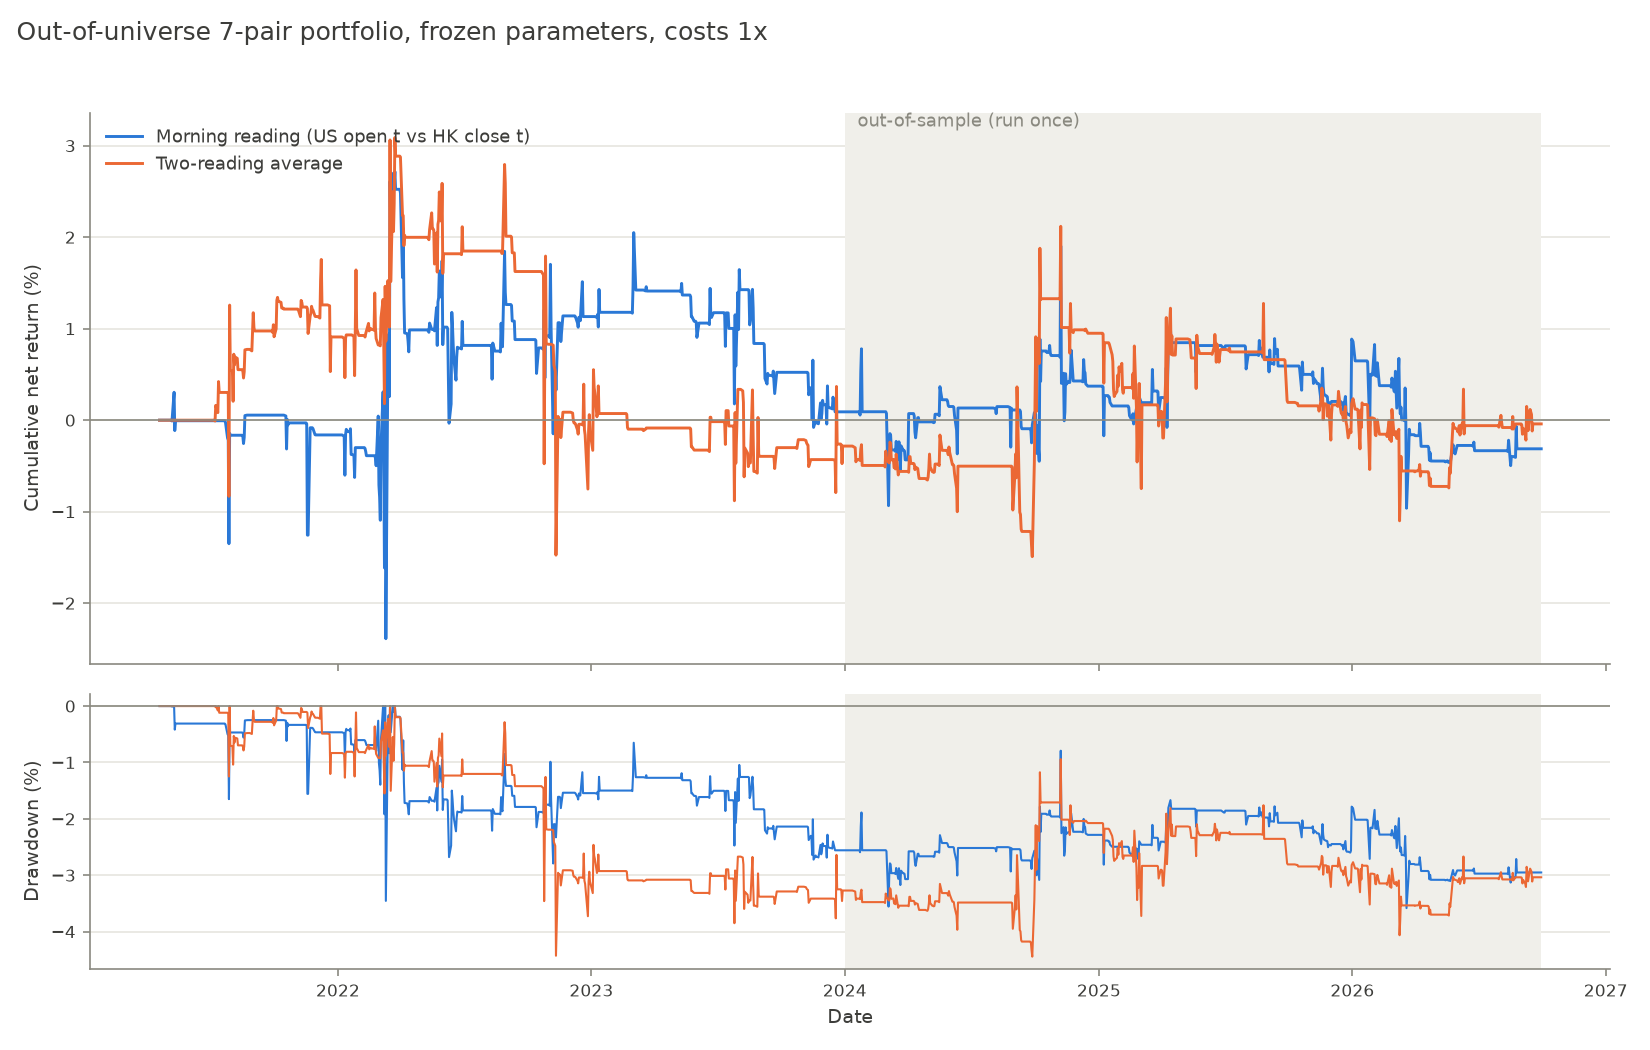

In [15]:
sel = pd.read_csv(config.LOG_DIR / "holdout_selection.csv")
display(sel.assign(half_spread_pct=sel["half_spread"] * 100)[["name", "us", "hk", "ratio", "median_hk_value_hkd_m", "half_spread_pct",
                                                               "implied_ratio_median", "decision", "reasons"]].round(2).fillna(""))
H_PAIRS, H_SPREADS = holdout.universe()
h_frames = holdout.load_frames(H_PAIRS)
h_spreads = spread.build_spreads(clean.clean_all(h_frames, pairs=H_PAIRS, log_prefix="holdout_"))
h_rows, h_runs = [], {}
for per, (a, b) in PERIODS.items():
    for sig in ("spread", "spread_2r"):
        for case, m, br in [("gross", 0.0, None), ("net, borrow 1%", 1.0, None), ("net, borrow 5%", 1.0, config.HOLDOUT_BORROW_SENSITIVITY)]:
            r = backtest.run_backtest(h_spreads, h_frames, FROZEN, signal=sig, start=a, end=b, cost_multiplier=m,
                                      pairs=H_PAIRS, half_spreads=H_SPREADS, borrow_annual=br)
            h_runs[per, sig, case] = r
            h_rows.append({"period": per, "signal": sig, "case": case, "sharpe": metrics.sharpe(r["portfolio"]["portfolio_ret"])})
h_res = pd.DataFrame(h_rows).pivot_table(index=["signal", "period"], columns="case", values="sharpe")
display(h_res.round(2))
hg = pd.read_csv(config.LOG_DIR / "holdout_dividend_corrections.csv").query("status != 'matched'")
for g in hg.itertuples():
    ex = g.hk_ex if isinstance(g.hk_ex, str) else g.us_ex
    per = "OOS" if ex >= config.OOS_START else "IS"
    print(f"Data gap: {g.pair} {g.status} on {ex}; position open across it:",
          {s: open_over(h_runs[per, s, "net, borrow 1%"], g.pair, ex) for s in ("spread", "spread_2r")})
plots.plot_equity_is_oos({plots.MEASURE_LABELS[s]: (h_runs["IS", s, "net, borrow 1%"]["portfolio"]["portfolio_ret"],
                                                    h_runs["OOS", s, "net, borrow 1%"]["portfolio"]["portfolio_ret"]) for s in ("spread", "spread_2r")},
                         config.FIGURES_DIR / "holdout_equity_is_oos.png",
                         title="Out-of-universe 7-pair portfolio, frozen parameters, costs 1x")
display(Image(str(config.FIGURES_DIR / "holdout_equity_is_oos.png")))

## 10. Conclusion

The summary below is printed from the results above, so its numbers cannot drift from the code.

In [16]:
g = lambda sig, per: res.loc[(sig, per)]
print("MAIN BASKET (6 pairs), frozen parameters, costs 1x")
for sig, label in (("spread", "morning (primary)"), ("spread_2r", "two-reading (pre-registered secondary)")):
    print(f"  {label:40s} net Sharpe IS {g(sig, 'IS')['sharpe']:+.2f} -> OOS {g(sig, 'OOS')['sharpe']:+.2f} "
          f"(gross OOS {g(sig, 'OOS')['sharpe_gross']:+.2f}; OOS t = {oos_t[sig]:.2f}; OOS annual return {pct(g(sig, 'OOS')['ann_return'])}; "
          f"break-even costs {sens.loc[(sig, 'OOS'), 'break-even x']:.2f}x)")
    c = conc[sig]; print(f"  {'':40s} top 3 OOS trades = {c['top3_share']:.0%} of profit; without them {pct(c['total_without_top3'])}")
print("OUT-OF-UNIVERSE (7 unseen pairs), costs 1x, borrow 1%")
for sig in ("spread", "spread_2r"):
    print(f"  {sig:40s} net Sharpe IS {h_res.loc[(sig, 'IS'), 'net, borrow 1%']:+.2f}, OOS {h_res.loc[(sig, 'OOS'), 'net, borrow 1%']:+.2f} "
          f"(gross OOS {h_res.loc[(sig, 'OOS'), 'gross']:+.2f})")
alb = vs[(vs["stat"] == "mean")].set_index("measure")
print("STOCK CONNECT (Alibaba): change in spread level vs controls (rank among 6):",
      {m: alb.loc[m, "treated_rank_of_n"] for m in alb.index})

MAIN BASKET (6 pairs), frozen parameters, costs 1x
  morning (primary)                        net Sharpe IS +0.06 -> OOS +0.22 (gross OOS +0.88; OOS t = 0.37; OOS annual return +0.40%; break-even costs 1.34x)
                                           top 3 OOS trades = 131% of profit; without them -0.29%
  two-reading (pre-registered secondary)   net Sharpe IS +0.08 -> OOS +0.50 (gross OOS +1.16; OOS t = 0.83; OOS annual return +1.29%; break-even costs 1.78x)
                                           top 3 OOS trades = 82% of profit; without them +0.49%
OUT-OF-UNIVERSE (7 unseen pairs), costs 1x, borrow 1%
  spread                                   net Sharpe IS +0.03, OOS -0.04 (gross OOS +0.75)
  spread_2r                                net Sharpe IS -0.00, OOS +0.04 (gross OOS +0.68)
STOCK CONNECT (Alibaba): change in spread level vs controls (rank among 6): {'spread': '3 of 6', 'spread_2r': '5 of 6'}


**Verdict.**

1. The ADR–HK gap is mostly **timing noise** from non-overlapping trading hours, with a small genuine mispricing on
   top. The placebo test shows the engine does not turn the noise into profit.
2. That mispricing produces a **real gross edge** — in the main basket and in seven unseen pairs — but **realistic
   costs absorb it**; break-even sits only modestly above modelled costs, and those costs are optimistic.
3. Out-of-sample net Sharpe ratios are **not distinguishable from zero**, profits are concentrated in a few
   shock-driven trades, and the best main-basket result does not replicate in the unseen pairs.
   **Falsification test (c) fails: the hypothesis is not supported after costs.**
4. **Stock Connect** inclusion left no detectable mark on Alibaba's spread.

**Limitations.** Daily data only (no intraday fills or market impact); costs held constant (HK stamp duty was 0.13%
until Nov 2023); borrow assumed available at the open; ~2.7 years per period gives Sharpe standard errors of ~0.6;
one formal Connect event. **What would change the answer:** materially lower costs (e.g. stamp-duty-exempt market
makers) or intraday execution closer to the moment the gap is measured.